In [1]:
# Data anaysis
import pandas as pd
import numpy as np

# Plotting and Correlation Maths
import seaborn as sns
import scipy as sci

# Simple model development
import sklearn as sk
from sklearn.preprocessing import MinMaxScaler, StandardScaler

import matplotlib.pyplot as plt

import plotly as px


import os

# Read Data

In [2]:
# get data
data = pd.read_csv('../data/processed/cleaned_data.csv')

In [3]:
data

,tempmax,tempmin,temp,feelslikemax,feelslikemin,feelslike,dew,humidity,precip,precipcover,...,preciptype_freezingrain,"preciptype_freezingrain,snow","preciptype_freezingrain,snow,ice",preciptype_none,preciptype_rain,"preciptype_rain,freezingrain","preciptype_rain,freezingrain,snow","preciptype_rain,snow","preciptype_rain,snow,ice",preciptype_snow
0,26.2,-4.2,10.1,18.1,-16.6,0.6,-3.8,57.2,0.000,0.00,...,0,0,0,1,0,0,0,0,0,0
1,35.8,28.0,32.5,34.7,24.1,26.8,26.6,78.9,0.000,0.00,...,0,0,0,1,0,0,0,0,0,0
2,15.3,2.5,9.2,14.6,-6.0,3.5,0.5,68.0,0.000,0.00,...,0,0,0,1,0,0,0,0,0,0
3,15.3,2.5,9.2,14.6,-6.0,3.5,0.5,68.0,0.000,0.00,...,0,0,0,1,0,0,0,0,0,0
4,15.3,2.5,9.2,14.6,-6.0,3.5,0.5,68.0,0.000,0.00,...,0,0,0,1,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3679,68.8,58.9,61.6,68.8,58.9,61.6,56.7,84.8,1.526,83.33,...,0,0,0,0,1,0,0,0,0,0
3680,59.4,46.8,50.8,59.4,39.8,46.5,46.3,84.5,0.266,83.33,...,0,0,0,0,1,0,0,0,0,0
3681,59.2,44.5,51.1,59.2,37.4,47.9,33.0,51.5,0.019,12.50,...,0,0,0,0,1,0,0,0,0,0
3682,81.1,45.0,64.1,79.9,39.9,62.9,39.5,42.6,0.001,4.17,...,0,0,0,0,1,0,0,0,0,0


# Scale the Data for SVD

In [4]:
scaler = StandardScaler()

scaled_data = scaler.fit_transform(data)

In [5]:
scaled_data_df = pd.DataFrame(scaled_data, columns=data.columns)
scaled_data_df

,tempmax,tempmin,temp,feelslikemax,feelslikemin,feelslike,dew,humidity,precip,precipcover,...,preciptype_freezingrain,"preciptype_freezingrain,snow","preciptype_freezingrain,snow,ice",preciptype_none,preciptype_rain,"preciptype_rain,freezingrain","preciptype_rain,freezingrain,snow","preciptype_rain,snow","preciptype_rain,snow,ice",preciptype_snow
0,-2.072065,-3.155709,-2.681172,-2.200051,-3.053488,-2.664663,-2.760187,-0.871929,-0.431235,-0.714985,...,-0.049487,-0.052171,-0.032969,1.297373,-0.956952,-0.057166,-0.032969,-0.338637,-0.04039,-0.188184
1,-1.533370,-1.159988,-1.333912,-1.372703,-0.981127,-1.320704,-0.991367,0.695315,-0.431235,-0.714985,...,-0.049487,-0.052171,-0.032969,1.297373,-0.956952,-0.057166,-0.032969,-0.338637,-0.04039,-0.188184
2,-2.683709,-2.740451,-2.735303,-2.374492,-2.513758,-2.515904,-2.509992,-0.091918,-0.431235,-0.714985,...,-0.049487,-0.052171,-0.032969,1.297373,-0.956952,-0.057166,-0.032969,-0.338637,-0.04039,-0.188184
3,-2.683709,-2.740451,-2.735303,-2.374492,-2.513758,-2.515904,-2.509992,-0.091918,-0.431235,-0.714985,...,-0.049487,-0.052171,-0.032969,1.297373,-0.956952,-0.057166,-0.032969,-0.338637,-0.04039,-0.188184
4,-2.683709,-2.740451,-2.735303,-2.374492,-2.513758,-2.515904,-2.509992,-0.091918,-0.431235,-0.714985,...,-0.049487,-0.052171,-0.032969,1.297373,-0.956952,-0.057166,-0.032969,-0.338637,-0.04039,-0.188184
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3679,0.318396,0.755160,0.416323,0.326850,0.790818,0.464403,0.759998,1.121433,4.714725,3.110540,...,-0.049487,-0.052171,-0.032969,-0.770789,1.044985,-0.057166,-0.032969,-0.338637,-0.04039,-0.188184
3680,-0.209077,0.005215,-0.233248,-0.141648,-0.181715,-0.310169,0.154875,1.099766,0.465768,3.110540,...,-0.049487,-0.052171,-0.032969,-0.770789,1.044985,-0.057166,-0.032969,-0.338637,-0.04039,-0.188184
3681,-0.220300,-0.137336,-0.215205,-0.151616,-0.303918,-0.238355,-0.618983,-1.283602,-0.367163,-0.141133,...,-0.049487,-0.052171,-0.032969,-0.770789,1.044985,-0.057166,-0.032969,-0.338637,-0.04039,-0.188184
3682,1.008599,-0.106347,0.566687,0.880077,-0.176623,0.531088,-0.240782,-1.926389,-0.427862,-0.523548,...,-0.049487,-0.052171,-0.032969,-0.770789,1.044985,-0.057166,-0.032969,-0.338637,-0.04039,-0.188184


In [6]:
scaled_data_df.describe()

,tempmax,tempmin,temp,feelslikemax,feelslikemin,feelslike,dew,humidity,precip,precipcover,...,preciptype_freezingrain,"preciptype_freezingrain,snow","preciptype_freezingrain,snow,ice",preciptype_none,preciptype_rain,"preciptype_rain,freezingrain","preciptype_rain,freezingrain,snow","preciptype_rain,snow","preciptype_rain,snow,ice",preciptype_snow
count,3.684000e+03,3.684000e+03,3.684000e+03,3.684000e+03,3.684000e+03,3.684000e+03,3.684000e+03,3.684000e+03,3.684000e+03,3.684000e+03,...,3.684000e+03,3.684000e+03,3.684000e+03,3.684000e+03,3.684000e+03,3.684000e+03,3.684000e+03,3.684000e+03,3.684000e+03,3.684000e+03
mean,-4.088900e-16,3.471707e-16,9.257886e-17,-1.311534e-16,-1.234385e-16,2.391621e-16,-1.542981e-16,3.857452e-16,-6.171924e-17,-1.542981e-17,...,-1.157236e-17,-1.542981e-17,-1.157236e-17,-7.714905e-17,4.628943e-17,-4.628943e-17,-1.350108e-17,-3.085962e-17,3.857452e-18,-3.085962e-17
std,1.000136e+00,1.000136e+00,1.000136e+00,1.000136e+00,1.000136e+00,1.000136e+00,1.000136e+00,1.000136e+00,1.000136e+00,1.000136e+00,...,1.000136e+00,1.000136e+00,1.000136e+00,1.000136e+00,1.000136e+00,1.000136e+00,1.000136e+00,1.000136e+00,1.000136e+00,1.000136e+00
min,-2.902554e+00,-3.205292e+00,-3.060089e+00,-2.967591e+00,-3.756156e+00,-3.372550e+00,-2.952197e+00,-3.125295e+00,-4.312346e-01,-7.149849e-01,...,-4.948717e-02,-5.217115e-02,-3.296902e-02,-7.707886e-01,-9.569517e-01,-5.716620e-02,-3.296902e-02,-3.386366e-01,-4.038962e-02,-1.881838e-01
25%,-8.207206e-01,-8.624894e-01,-8.527477e-01,-8.493800e-01,-8.741995e-01,-8.641677e-01,-8.459044e-01,-6.642873e-01,-4.312346e-01,-7.149849e-01,...,-4.948717e-02,-5.217115e-02,-3.296902e-02,-7.707886e-01,-9.569517e-01,-5.716620e-02,-3.296902e-02,-3.386366e-01,-4.038962e-02,-1.881838e-01
50%,2.061676e-01,4.860062e-02,1.035666e-01,2.271696e-01,1.085172e-01,1.771444e-01,3.268714e-02,8.502896e-02,-4.143737e-01,-5.235480e-01,...,-4.948717e-02,-5.217115e-02,-3.296902e-02,-7.707886e-01,-9.569517e-01,-5.716620e-02,-3.296902e-02,-3.386366e-01,-4.038962e-02,-1.881838e-01
75%,8.683140e-01,9.240528e-01,9.035024e-01,8.152846e-01,9.295693e-01,8.799019e-01,9.112787e-01,7.530941e-01,-5.860779e-02,4.327184e-01,...,-4.948717e-02,-5.217115e-02,-3.296902e-02,1.297373e+00,1.044985e+00,-5.716620e-02,-3.296902e-02,-3.386366e-01,-4.038962e-02,-1.881838e-01
max,1.715637e+00,1.784010e+00,1.721482e+00,1.911770e+00,1.636056e+00,1.777585e+00,1.795689e+00,2.161447e+00,1.279449e+01,3.875828e+00,...,2.020726e+01,1.916768e+01,3.033150e+01,1.297373e+00,1.044985e+00,1.749286e+01,3.033150e+01,2.953018e+00,2.475884e+01,5.313953e+00


# Perform SVD

In [7]:
U, S, V = sci.linalg.svd(scaled_data)

In [8]:
S

array([1.72914301e+02, 1.19750612e+02, 7.14021186e+01, 6.82792702e+01,
       6.48266810e+01, 6.19597871e+01, 6.11608737e+01, 6.09943487e+01,
       6.08499106e+01, 6.07404967e+01, 5.94783658e+01, 5.75535635e+01,
       5.32134990e+01, 4.79005818e+01, 4.52263046e+01, 4.07143322e+01,
       3.23696250e+01, 3.07796613e+01, 2.93955650e+01, 1.65426231e+01,
       5.74898987e+00, 4.98363320e+00, 3.56040349e+00, 2.30321170e+00,
       1.18525850e+00, 4.45168621e-14])

# Plot Singular Values

Use these to determine variance cutoff

In [9]:
s_values = np.cumsum(S**2) / sum(S**2)
print(s_values)

[0.14014389 0.23719958 0.2950697  0.3504088  0.40294965 0.45316693
 0.5027367  0.55217151 0.60148925 0.65071832 0.69892445 0.74557057
 0.78869914 0.82752169 0.86417678 0.89717501 0.92341    0.94835636
 0.97218093 0.98558842 0.99024787 0.99428702 0.99717266 0.99903937
 1.         1.        ]


<function matplotlib.pyplot.show(close=None, block=None)>

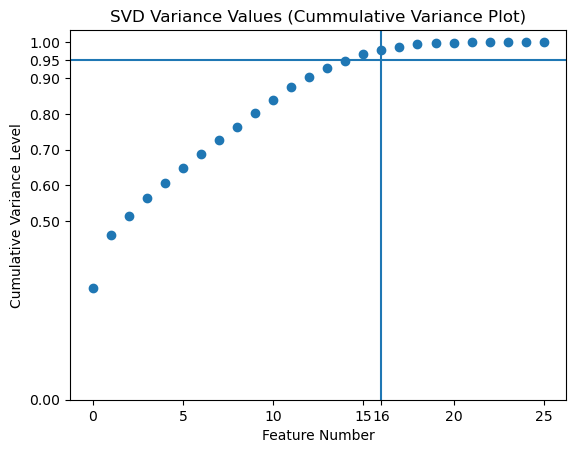

In [10]:
# Create plot
fig, ax = plt.subplots()
plt.scatter(range(0,len(s_values)),s_values)
plt.axhline(0.95)
plt.axvline(16)
plt.xlabel('Feature Number')
plt.ylabel('Cumulative Variance Level')
plt.title('SVD Variance Values (Cumulative Variance Plot)')

xt = [0, 5, 10, 15, 16, 20, 25]
yt = [0,  0.5, 0.6, 0.7, 0.8, 0.9, 0.95, 1.0]
plt.xticks(ticks=xt)
plt.yticks(ticks=yt)

plt.show

Variance cutoff can be done around 15-17 features.  The plot shows the intersection at 95% variance and 16 S values.

This will allow us to drop around 10 features and still have reasonable outputs from the model.

# A BETTER METHOD

In [13]:
from sklearn.decomposition import TruncatedSVD, PCA

In [14]:
pca = PCA(n_components=26, svd_solver='full')
pca.fit(scaled_data)

out = pca.transform(scaled_data)

In [15]:
sum(pca.explained_variance_ratio_)

0.9999999999999997

In [16]:
ratios = pca.explained_variance_ratio_
ratios

array([3.12153966e-01, 1.49714034e-01, 5.32266615e-02, 4.86726253e-02,
       4.38747450e-02, 4.00799217e-02, 3.90529992e-02, 3.88406266e-02,
       3.86568907e-02, 3.85179982e-02, 3.69338929e-02, 3.45821084e-02,
       2.95631471e-02, 2.39545825e-02, 2.13544917e-02, 1.73061978e-02,
       1.09391195e-02, 9.89087475e-03, 9.02133178e-03, 2.85703644e-03,
       3.45056424e-04, 2.59298002e-04, 1.32344369e-04, 5.53827795e-05,
       1.46667263e-05, 1.28314364e-32])

In [17]:
r_values = np.cumsum(ratios) / sum(ratios)
print(np.cumsum(ratios)/sum(ratios))

[0.31215397 0.461868   0.51509466 0.56376729 0.60764203 0.64772195
 0.68677495 0.72561558 0.76427247 0.80279047 0.83972436 0.87430647
 0.90386962 0.9278242  0.94917869 0.96648489 0.97742401 0.98731488
 0.99633622 0.99919325 0.99953831 0.99979761 0.99992995 0.99998533
 1.         1.        ]


<function matplotlib.pyplot.show(close=None, block=None)>

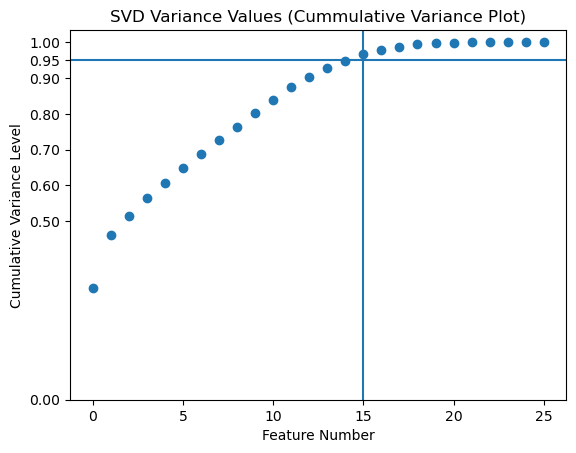

In [18]:
# Create plot
fig, ax = plt.subplots()
plt.scatter(range(0,len(r_values)),r_values)
plt.axhline(0.95)
plt.axvline(15)
plt.xlabel('Feature Number')
plt.ylabel('Cumulative Variance Level')
plt.title('SVD Variance Values (Cummulative Variance Plot)')

xt = [0, 5, 10, 15, 20, 25]
yt = [0,  0.5, 0.6, 0.7, 0.8, 0.9, 0.95, 1.0]
plt.xticks(ticks=xt)
plt.yticks(ticks=yt)

plt.show